In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [2]:
class CalculateRecord(TypedDict):
    runs: int
    balls : int
    fours: int
    sixes: int
    StrikeRate: float
    BallPerBoundary: float
    BoundaryPercentage: float
    summary: str

In [6]:
def StrikeRateCalculator(state: CalculateRecord):
    runs = state['runs']
    balls = state['balls']
    sr = ((runs/balls)*100)
    
    return {"StrikeRate":sr}

def BallPerBoundaryCalculator(state: CalculateRecord):
    bpb = state['balls']/(state['fours'] + state['sixes'])

    return {'BallPerBoundary': bpb}

def BoundaryPercentageCalculator(state: CalculateRecord):
    boundary_percent = (((state['fours'] * 4) + (state['sixes'] * 6))/state['runs'])*100

    return {'BoundaryPercentage': boundary_percent}

def Summary(state: CalculateRecord):
    summary = f"""
    Strike Rate - {state['StrikeRate']} \n
    Balls per boundary - {state['BallPerBoundary']} \n
    Boundary percent - {state['BoundaryPercentage']}
    """
        
    return {'summary': summary}


In [7]:
graph = StateGraph(CalculateRecord)

graph.add_node("StrikeRateCalculator",StrikeRateCalculator)
graph.add_node("BallPerBoundaryCalculator",BallPerBoundaryCalculator)
graph.add_node("BoundaryPercentageCalculator",BoundaryPercentageCalculator)
graph.add_node("Summary",Summary)


graph.add_edge(START,"StrikeRateCalculator")
graph.add_edge(START,"BallPerBoundaryCalculator")
graph.add_edge(START,"BoundaryPercentageCalculator")

graph.add_edge("StrikeRateCalculator","Summary")
graph.add_edge("BallPerBoundaryCalculator","Summary")
graph.add_edge("BoundaryPercentageCalculator","Summary")

graph.add_edge("Summary", END)

wf=graph.compile()

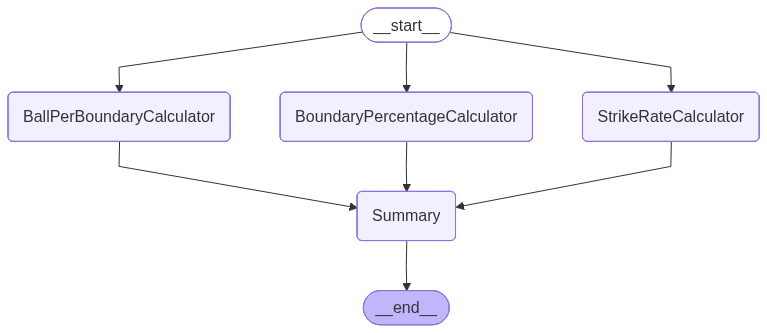

In [8]:
wf

In [9]:

intial_state = {
    'runs': 100,
    'balls': 50,
    'fours': 6,
    'sixes': 4
}

wf.invoke(intial_state)

{'runs': 100,
 'balls': 50,
 'fours': 6,
 'sixes': 4,
 'StrikeRate': 200.0,
 'BallPerBoundary': 5.0,
 'BoundaryPercentage': 48.0,
 'summary': '\n    Strike Rate - 200.0 \n\n    Balls per boundary - 5.0 \n\n    Boundary percent - 48.0\n    '}